# HDFC Bank Stock Price Prediction using LSTM

**Objective:** Use five years of daily HDFC Bank market data to predict the next trading day's **Adjusted Close** price using an LSTM model.

### Project flow
1. Download and inspect five years of HDFC Bank data
2. Exploratory data analysis
3. Feature engineering
4. Chronological train / validation / test split
5. Scale features using training data only
6. Create 60-day sequences
7. Train an LSTM model
8. Compare against a naive next-day baseline
9. Evaluate using MAE, RMSE and MAPE
10. Visualize actual vs predicted prices

> **Important:** This is a forecasting exercise, not investment advice. Stock prices are noisy and difficult to predict consistently.


In [ ]:
# Run this cell only if the required packages are not installed.
# In VS Code / Jupyter, uncomment the line below if needed.

%pip install yfinance tensorflow scikit-learn pandas numpy matplotlib


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 1. Download the data

We use HDFC Bank's NSE ticker **HDFCBANK.NS** and retrieve approximately five years of daily market data.

The model will use **Adjusted Close** as the prediction target because it accounts for relevant corporate actions more appropriately than the raw closing price.


In [ ]:
ticker = "HDFCBANK.NS"

data = yf.download(
    ticker,
    start="2021-08-30",
    end="2026-08-29",
    auto_adjust=False,
    progress=True
)

# yfinance may return a MultiIndex even for a single ticker.
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data = data.reset_index()

print("Shape:", data.shape)
display(data.head())
display(data.tail())


[*********************100%***********************]  1 of 1 completed

Shape: (1240, 7)


Price,Date,Adj Close,Close,High,Low,Open,Volume
0,2021-08-30,733.782166,784.125000,785.000000,775.799988,777.799988,9049166
1,2021-08-31,739.935120,790.700012,791.674988,781.099976,781.750000,12062576
2,2021-09-01,738.858826,789.549988,799.000000,787.250000,787.500000,12422558
3,2021-09-02,743.491089,794.500000,796.000000,785.625000,787.049988,9618524
4,2021-09-03,737.431824,788.025024,799.000000,784.150024,793.049988,10735334


Price,Date,Adj Close,Close,High,Low,Open,Volume
1235,2026-08-24,729.000000,729.000000,734.400024,724.099976,732.500000,11408345
1236,2026-08-25,727.500000,727.500000,728.700012,722.000000,726.599976,17511874
1237,2026-08-26,727.200012,727.200012,731.000000,724.150024,728.000000,21156463
1238,2026-08-27,711.000000,711.000000,728.150024,710.000000,728.150024,46515020
1239,2026-08-28,720.299988,720.299988,720.299988,707.000000,710.849976,16494301


In [ ]:
print("Columns:", list(data.columns))
print("\nMissing values:")
print(data.isna().sum())

print("\nDuplicate rows:", data.duplicated().sum())

data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values("Date").drop_duplicates("Date").reset_index(drop=True)

print("\nDate range:", data["Date"].min().date(), "to", data["Date"].max().date())
print("Number of trading observations:", len(data))


Columns: ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

Missing values:
Price
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Duplicate rows: 0

Date range: 2021-08-30 to 2026-08-28
Number of trading observations: 1240


## 2. Exploratory Data Analysis

First, inspect the long-term price trend and trading volume. These plots help establish how the series behaves before modelling it.


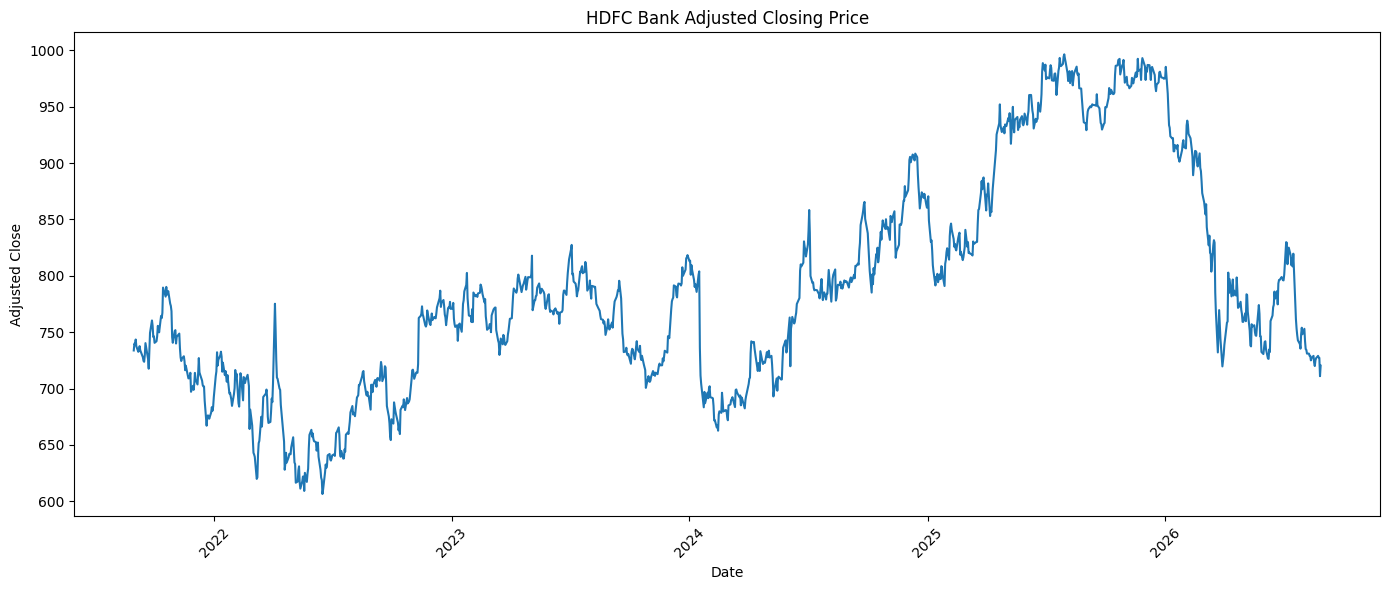

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(data["Date"], data["Adj Close"])
ax.set_title("HDFC Bank Adjusted Closing Price")
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Close")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


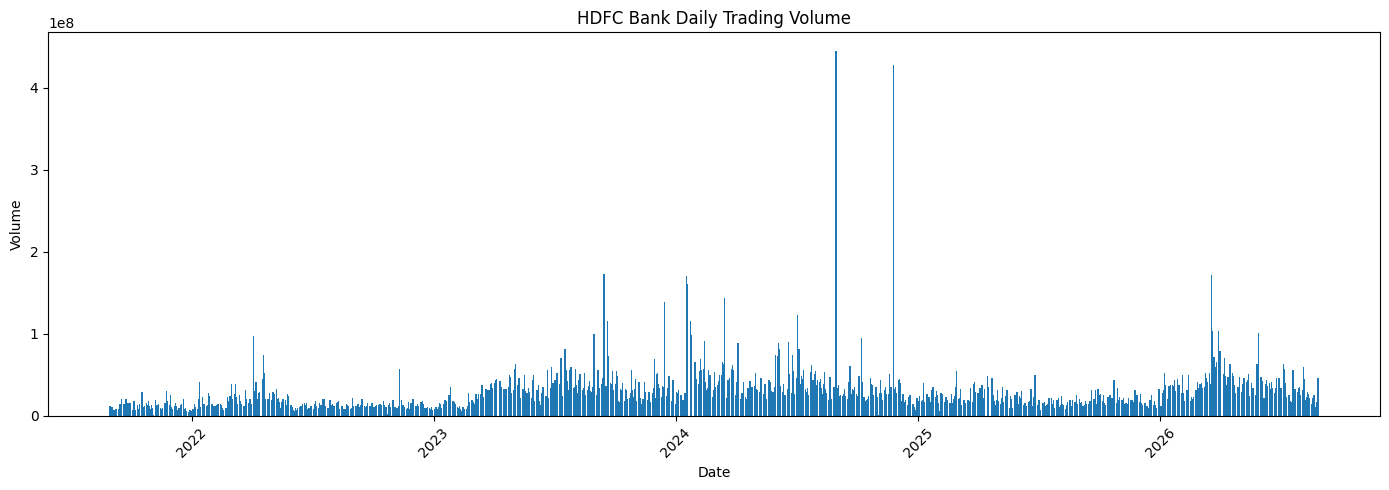

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(data["Date"], data["Volume"], width=2)
ax.set_title("HDFC Bank Daily Trading Volume")
ax.set_xlabel("Date")
ax.set_ylabel("Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Daily returns and volatility

Price levels often show a strong trend, while returns are useful for understanding day-to-day movement. We also calculate rolling volatility to see how market variability changes over time.


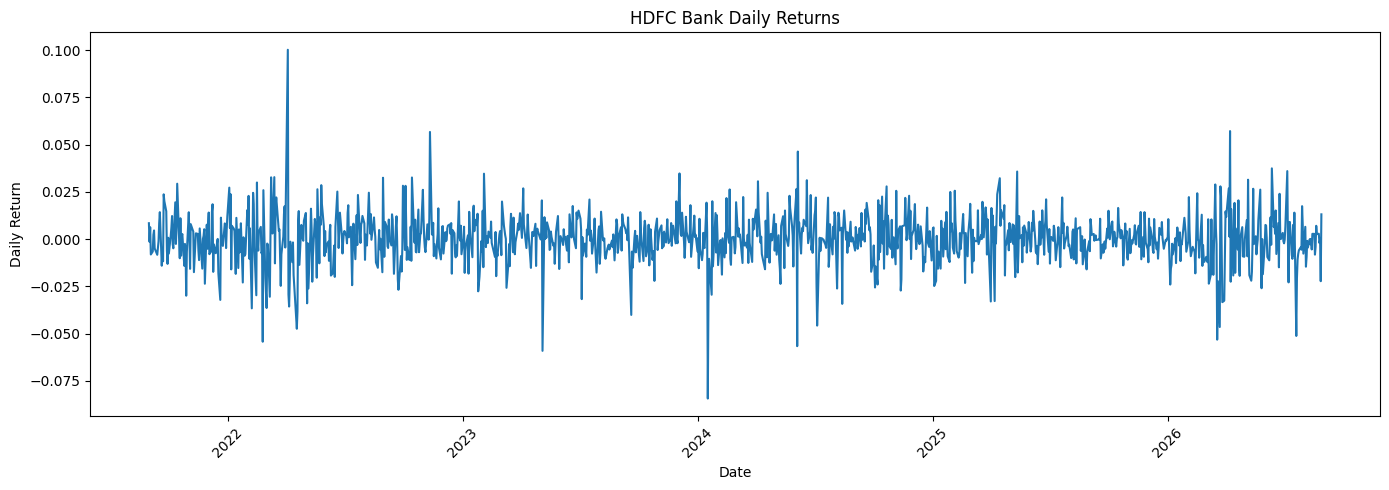

In [ ]:
data["Daily_Return"] = data["Adj Close"].pct_change()

data["Rolling_Volatility_21D"] = (
    data["Daily_Return"].rolling(window=21).std()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(data["Date"], data["Daily_Return"])
ax.set_title("HDFC Bank Daily Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Return")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


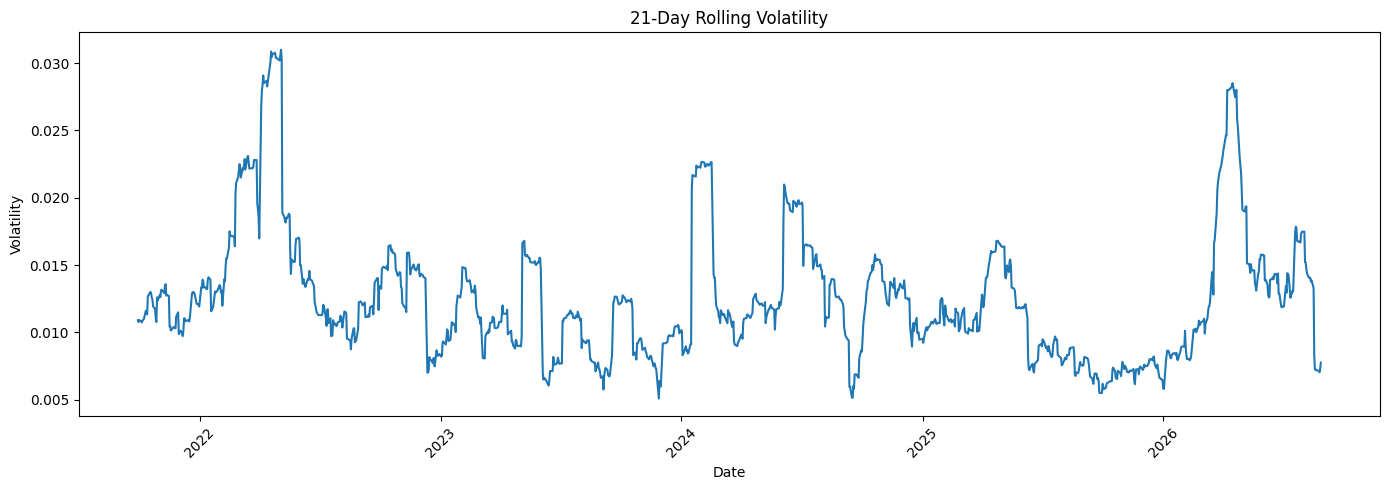

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(data["Date"], data["Rolling_Volatility_21D"])
ax.set_title("21-Day Rolling Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Volatility")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 3. Feature Engineering

We create features using information available up to each trading day:

- 7-day moving average
- 21-day moving average
- Daily return
- 21-day rolling volatility
- Daily volume change

The target remains the next trading day's **Adjusted Close**.

The sequence model will only see historical observations, so future information is not used to construct the input sequence.


In [ ]:
df = data.copy()

# Target: next trading day's return
df["Target_Return"] = df["Adj Close"].shift(-1) / df["Adj Close"] - 1

# Basic technical features
df["MA_7"] = df["Adj Close"].rolling(7).mean()
df["MA_21"] = df["Adj Close"].rolling(21).mean()
df["Daily_Return"] = df["Adj Close"].pct_change()
df["Rolling_Volatility_21D"] = df["Daily_Return"].rolling(21).std()
df["Volume_Change"] = df["Volume"].pct_change()

df = df.replace([np.inf, -np.inf], np.nan)

feature_cols = [
    "Adj Close",
    "MA_7",
    "MA_21",
    "Daily_Return",
    "Rolling_Volatility_21D",
    "Volume_Change"
]

df = df.dropna(subset=feature_cols + ["Target_Return"]).reset_index(drop=True)

print("Features used:", feature_cols)
print("Number of features:", len(feature_cols))
print("Modeling data shape:", df.shape)

display(df[["Date"] + feature_cols + ["Target_Return"]].head())

Features used: ['Adj Close', 'MA_7', 'MA_21', 'Daily_Return', 'Rolling_Volatility_21D', 'Volume_Change']
Number of features: 6
Modeling data shape: (1213, 13)


Price,Date,Adj Close,MA_7,MA_21,Daily_Return,Rolling_Volatility_21D,Volume_Change,Target_Return
0,2021-09-29,745.760315,741.365470,736.373442,-0.013127,0.010900,0.273157,0.000690
1,2021-09-30,746.275085,744.239711,736.675345,0.000690,0.010762,-0.017690,-0.007681
2,2021-10-01,740.543274,747.515006,736.755557,-0.007681,0.010902,-0.303389,0.001927
3,2021-10-04,741.970337,748.567766,736.683140,0.001927,0.010821,-0.366405,0.006117
4,2021-10-05,746.508911,748.159999,737.115383,0.006117,0.010734,0.454707,0.012191


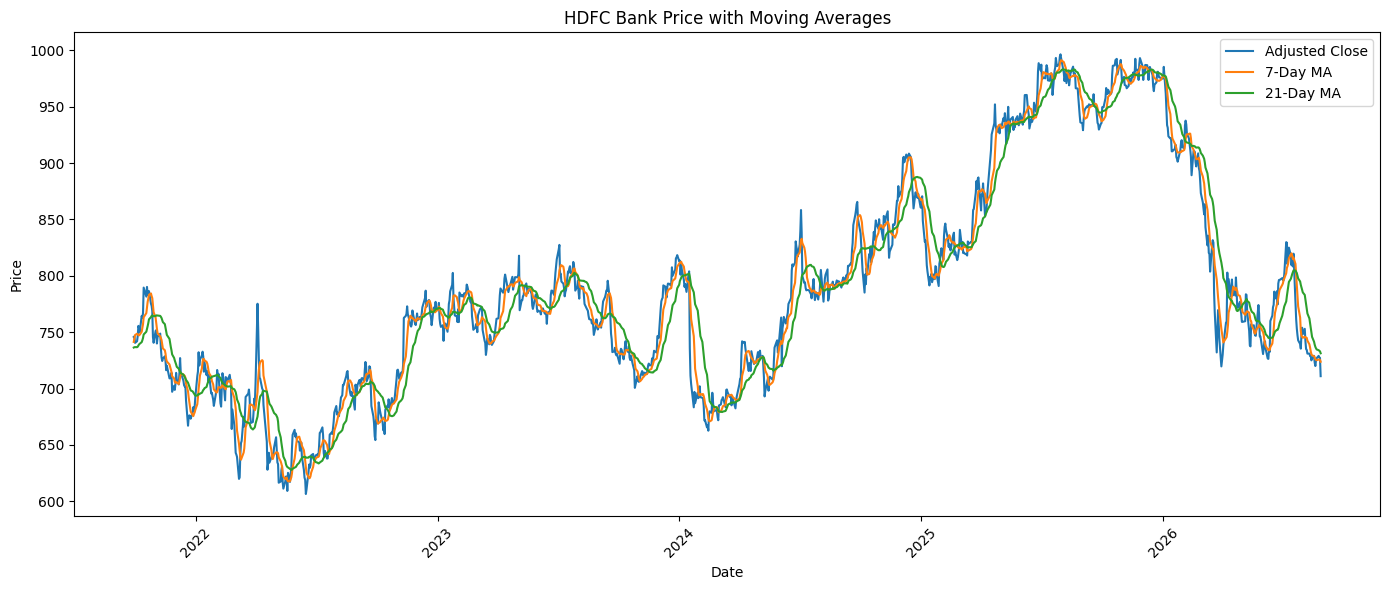

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df["Date"], df["Adj Close"], label="Adjusted Close")
ax.plot(df["Date"], df["MA_7"], label="7-Day MA")
ax.plot(df["Date"], df["MA_21"], label="21-Day MA")
ax.set_title("HDFC Bank Price with Moving Averages")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4. Chronological Train / Validation / Test Split

Because this is time-series data, we **do not randomly shuffle observations**.

- **Training:** first 70%
- **Validation:** next 15%
- **Test:** final 15%

The test set represents unseen future observations.


In [ ]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Training:", train_df["Date"].min().date(), "to", train_df["Date"].max().date(), "|", len(train_df), "rows")
print("Validation:", val_df["Date"].min().date(), "to", val_df["Date"].max().date(), "|", len(val_df), "rows")
print("Test:", test_df["Date"].min().date(), "to", test_df["Date"].max().date(), "|", len(test_df), "rows")


Training: 2021-09-29 to 2025-03-04 | 849 rows
Validation: 2025-03-05 to 2025-12-01 | 182 rows
Test: 2025-12-02 to 2026-08-27 | 182 rows


## 5. Scale the Features

MinMax scaling is fitted **only on the training data**. This prevents information from the validation/test period from leaking into the model during preprocessing.


In [ ]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_df[feature_cols])
val_scaled = scaler.transform(val_df[feature_cols])
test_scaled = scaler.transform(test_df[feature_cols])

print("Scaled training shape:", train_scaled.shape)
print("Scaled validation shape:", val_scaled.shape)
print("Scaled test shape:", test_scaled.shape)


Scaled training shape: (849, 6)
Scaled validation shape: (182, 6)
Scaled test shape: (182, 6)


In [ ]:
target_scaler = MinMaxScaler()

y_train_scaled = target_scaler.fit_transform(
    train_df[["Target_Return"]]
).ravel()

y_val_scaled = target_scaler.transform(
    val_df[["Target_Return"]]
).ravel()

y_test_scaled = target_scaler.transform(
    test_df[["Target_Return"]]
).ravel()

## 6. Create 60-Day Sequences

The LSTM receives the previous **60 trading days** and predicts the next day's Adjusted Close.

For example:

**Days 1–60 → Day 61**

**Days 2–61 → Day 62**

and so on.

For validation and test sequences, we include the immediately preceding history so that the first prediction in each period has access to the required 60-day lookback.


In [ ]:
LOOKBACK = 60

# Build validation/test inputs with the required historical context
val_input = np.vstack([train_scaled[-LOOKBACK:], val_scaled])
test_input = np.vstack([val_scaled[-LOOKBACK:], test_scaled])

def create_sequences(X_data, y_data, lookback):
    X, y = [], []

    for i in range(lookback, len(X_data)):
        X.append(X_data[i-lookback:i])
        y.append(y_data[i])

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(
    train_scaled,
    y_train_scaled,
    LOOKBACK
)

X_val, y_val = create_sequences(
    val_input,
    np.concatenate([y_train_scaled[-LOOKBACK:], y_val_scaled]),
    LOOKBACK
)

X_test, y_test = create_sequences(
    test_input,
    np.concatenate([y_val_scaled[-LOOKBACK:], y_test_scaled]),
    LOOKBACK
)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (789, 60, 6) y_train: (789,)
X_val: (182, 60, 6) y_val: (182,)
X_test: (182, 60, 6) y_test: (182,)


## 7. Build the LSTM Model

The model uses two LSTM layers with dropout regularization. Early stopping restores the weights from the epoch with the best validation loss.

The architecture is intentionally kept simple enough to explain and reproduce.


In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([
    LSTM(128, return_sequences=True,
         input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),

    LSTM(64),
    Dropout(0.2),

    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 128)        │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,641 (471.25 KB)

 Trainable params: 120,641 (471.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - loss: 0.0198 - val_loss: 0.0040
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0086 - val_loss: 0.0041
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0076 - val_loss: 0.0033
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 0.0074 - val_loss: 0.0031
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.0068 - val_loss: 0.0027
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0070 - val_loss: 0.0030
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0065 - val_loss: 0.0027
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - loss: 0.0068 - val_loss: 0.0029
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.0064 - val_loss: 0.0028
Epoch 10/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 0.0067 - val_loss: 0.0027
Epoch 11/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0067 - val_loss: 0.0035
Epoch 12/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/st

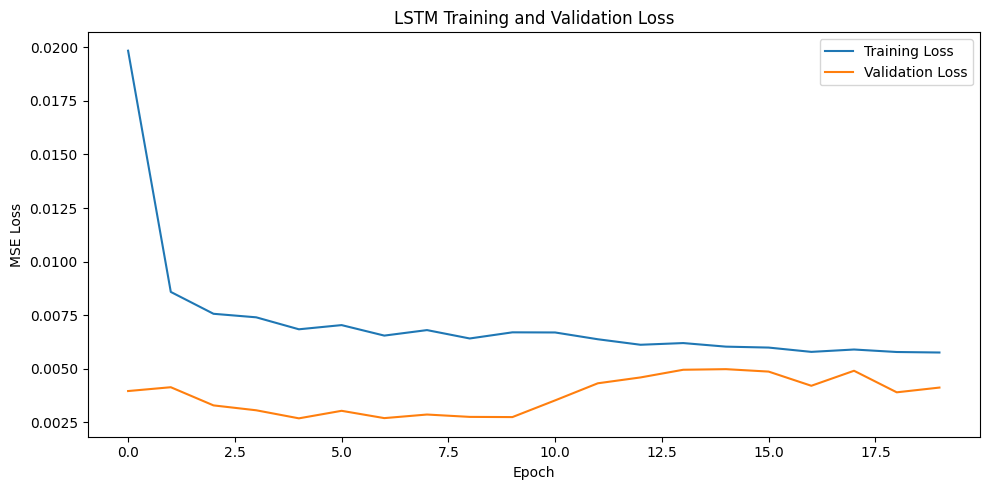

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history["loss"], label="Training Loss")
ax.plot(history.history["val_loss"], label="Validation Loss")
ax.set_title("LSTM Training and Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Generate Predictions

The model outputs scaled Adjusted Close values, so we transform them back to the original price scale.

To inverse-transform only the target column, the other feature positions are filled with zeros before applying the scaler's inverse transformation.


In [ ]:
# Generate Predictions

# Predict next-day returns
pred_scaled = model.predict(X_test, verbose=0).reshape(-1)

# Convert predicted returns back to original scale
pred_returns = target_scaler.inverse_transform(
    pred_scaled.reshape(-1, 1)
).ravel()

# Convert actual scaled returns back to original scale
actual_returns = target_scaler.inverse_transform(
    y_test.reshape(-1, 1)
).ravel()


# Previous day's actual price for each test prediction
# For the first test prediction, use the final validation-day price
previous_prices = np.concatenate([
    [val_df["Adj Close"].iloc[-1]],
    test_df["Adj Close"].values[:-1]
])

# Align with the number of LSTM predictions
previous_prices = previous_prices[-len(pred_returns):]


# Reconstruct predicted prices from predicted returns
pred_actual = previous_prices * (1 + pred_returns)


# Actual prices corresponding to each prediction
y_test_actual = test_df["Adj Close"].values[-len(pred_returns):]


print("Previous prices:", len(previous_prices))
print("LSTM predictions:", len(pred_actual))
print("Actual prices:", len(y_test_actual))

Previous prices: 182
LSTM predictions: 182
Actual prices: 182


## 9. Naive Baseline

A strong sanity check for time-series forecasting is a naive model:

> **Tomorrow's price = today's price**

If the LSTM cannot beat this simple baseline, its added complexity is not justified.

For the test period, the baseline prediction is the previous trading day's actual Adjusted Close.


In [ ]:
# Naive baseline: tomorrow's price = today's actual price

# The first test prediction needs the final validation-day price
history_prices = np.concatenate([
    val_df["Adj Close"].to_numpy(),
    test_df["Adj Close"].to_numpy()
])

# For each test day, use the price from the previous trading day
naive_pred = history_prices[-(len(test_df) + 1):-1]

# Actual test prices
naive_actual = test_df["Adj Close"].to_numpy()

print("LSTM predictions:", len(pred_actual))
print("Naive predictions:", len(naive_pred))
print("Naive actual values:", len(naive_actual))

LSTM predictions: 182
Naive predictions: 182
Naive actual values: 182


## 10. Model Evaluation

We report:

- **MAE:** average absolute prediction error
- **RMSE:** penalizes larger errors more strongly
- **MAPE:** average percentage error

Lower values are better.


In [ ]:
lstm_mae = mean_absolute_error(
    y_test_actual,
    pred_actual
)

lstm_rmse = np.sqrt(mean_squared_error(
    y_test_actual,
    pred_actual
))

lstm_mape = np.mean(
    np.abs(
        (y_test_actual - pred_actual) / y_test_actual
    )
) * 100


naive_mae = mean_absolute_error(
    naive_actual,
    naive_pred
)

naive_rmse = np.sqrt(mean_squared_error(
    naive_actual,
    naive_pred
))

naive_mape = np.mean(
    np.abs(
        (naive_actual - naive_pred) / naive_actual
    )
) * 100


results = pd.DataFrame({
    "Model": ["LSTM", "Naive Baseline"],
    "MAE": [lstm_mae, naive_mae],
    "RMSE": [lstm_rmse, naive_rmse],
    "MAPE (%)": [lstm_mape, naive_mape]
})

results

,Model,MAE,RMSE,MAPE (%)
0,LSTM,8.721502,11.981083,1.080628
1,Naive Baseline,8.496908,11.847116,1.050344


## 11. Actual vs Predicted Price

The final plot focuses on the held-out test period, showing how closely the LSTM tracks the actual HDFC Bank Adjusted Close.


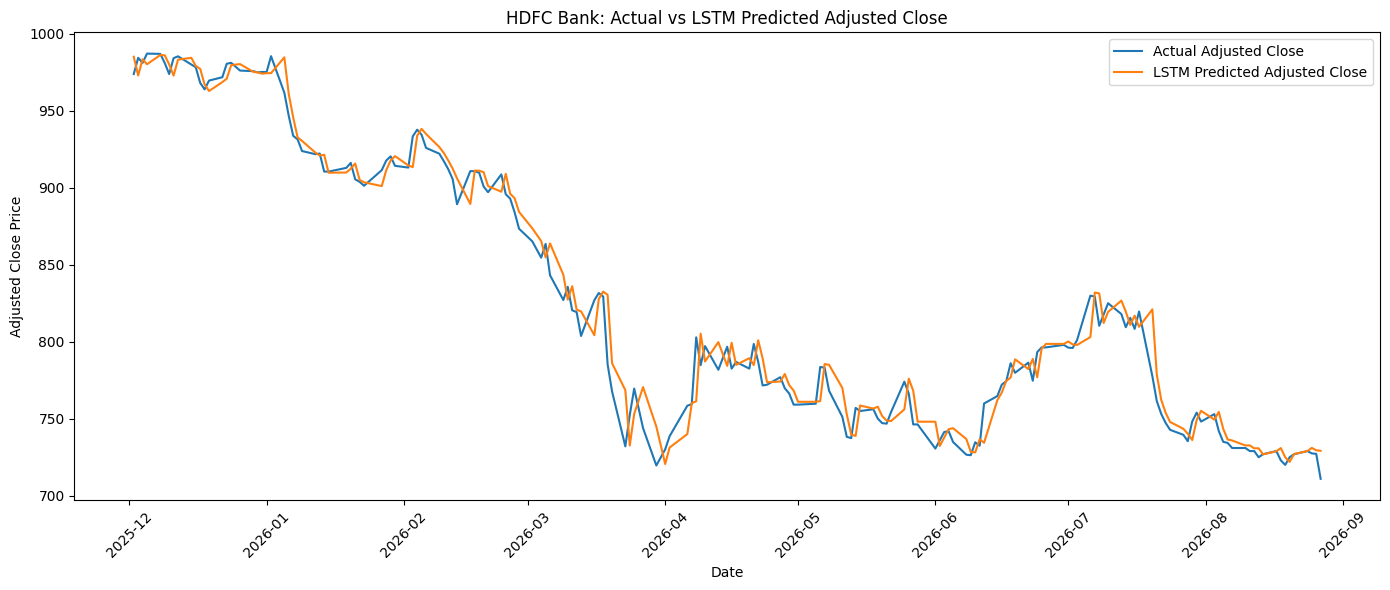

In [ ]:
# Actual vs Predicted Adjusted Close

test_dates = test_df["Date"].iloc[-len(pred_actual):].to_numpy()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    test_dates,
    y_test_actual,
    label="Actual Adjusted Close"
)

ax.plot(
    test_dates,
    pred_actual,
    label="LSTM Predicted Adjusted Close"
)

ax.set_title("HDFC Bank: Actual vs LSTM Predicted Adjusted Close")
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Close Price")
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 12. Prediction Error Analysis

Looking at the distribution of prediction errors helps identify whether the model systematically over- or under-predicts the stock price.


Prediction Error Statistics
---------------------------
Mean Error:   -2.4504
Median Error: -2.2666
Std Error:    11.7278
Min Error:    -45.1864
Max Error:    41.4926


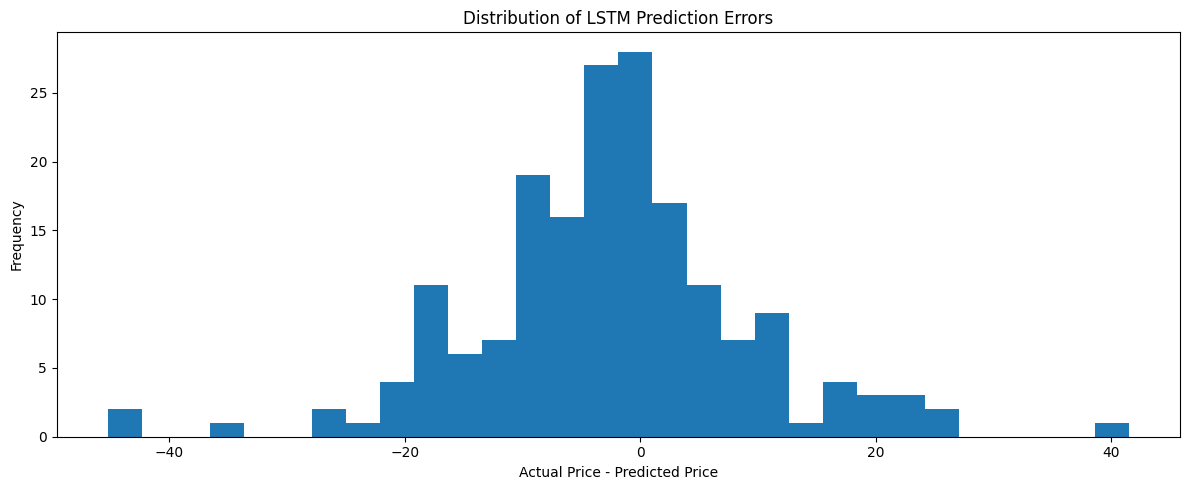

In [ ]:
# Prediction Error Analysis

errors = y_test_actual - pred_actual

print("Prediction Error Statistics")
print("---------------------------")
print(f"Mean Error:   {np.mean(errors):.4f}")
print(f"Median Error: {np.median(errors):.4f}")
print(f"Std Error:    {np.std(errors):.4f}")
print(f"Min Error:    {np.min(errors):.4f}")
print(f"Max Error:    {np.max(errors):.4f}")

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(errors, bins=30)

ax.set_title("Distribution of LSTM Prediction Errors")
ax.set_xlabel("Actual Price - Predicted Price")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 13. Final Takeaways

Use the results above to report:

1. The number of daily observations used.
2. The chronological train/validation/test periods.
3. The 60-day lookback window.
4. LSTM MAE, RMSE and MAPE.
5. Naive baseline MAE, RMSE and MAPE.
6. Whether the LSTM actually outperformed the naive baseline.
7. What the actual-vs-predicted plot suggests about model behaviour.

### Important interpretation

A lower prediction error does **not** imply that the model can reliably generate trading profits. Stock prices are influenced by many external factors that are not contained in historical price/volume data.


In [ ]:
# Model Comparison

comparison = pd.DataFrame({
    "Model": ["LSTM", "Naive Baseline"],
    "MAE": [lstm_mae, naive_mae],
    "RMSE": [lstm_rmse, naive_rmse],
    "MAPE (%)": [lstm_mape, naive_mape]
})

comparison = comparison.sort_values("RMSE")

comparison

,Model,MAE,RMSE,MAPE (%)
1,Naive Baseline,8.496908,11.847116,1.050344
0,LSTM,8.721502,11.981083,1.080628
